#  Datathon FIAP Fase 5 — Passos Mágicos
## Análise do Desenvolvimento Educacional e Predição de Risco de Defasagem

**Associação Passos Mágicos** — instrumento de transformação social por meio da educação para crianças e jovens em vulnerabilidade.

**Dataset:** Dados do desenvolvimento educacional dos anos **2022, 2023 e 2024**.

---


In [13]:
import os, re, sys, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dotenv import load_dotenv, find_dotenv

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, fbeta_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)
from sklearn.svm import SVC 


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

SEED    = 42
PALETTE = "Set2"


In [14]:
# ─── CONFIGURAÇÃO DE CAMINHOS E CARREGAMENTO ─────────────────────────────
import unicodedata
load_dotenv(find_dotenv())

DATA_PATH  = Path(os.getenv("DATA_PATH",  "dados/PEDE_PASSOS_DATASET_FIAP.xlsx"))
MODELS_DIR = Path(os.getenv("MODELS",     "modelo"))
PROC_DIR   = Path(os.getenv("PROCESSED",  "dados/processado"))

MODELS_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset   : {DATA_PATH}")
print(f"Modelos   : {MODELS_DIR}")
print(f"Processado: {PROC_DIR}")

# ─── Carregamento de múltiplas abas (uma por ano) ─────────────────────────────
def _norm_cols(df):
    """Normaliza nomes de colunas: minúsculas, sem acentos, espaços → underscore."""
    cols = []
    for c in df.columns.astype(str):
        c = ''.join(ch for ch in unicodedata.normalize('NFD', c)
                    if unicodedata.category(ch) != 'Mn')
        c = c.strip().lower()
        c = re.sub(r'[\s\-\.]+', '_', c)
        c = re.sub(r'[^a-z0-9_]', '', c)
        c = re.sub(r'_+', '_', c).strip('_')
        cols.append(c)
    df.columns = cols
    return df

planilhas = pd.read_excel(DATA_PATH, sheet_name=None)   # lê TODAS as abas
print(f"\nAbas encontradas: {list(planilhas.keys())}")

dfs = []
for sheet_name, sheet_df in planilhas.items():
    # Extrai ano dos dígitos do nome da aba: "PEDE2022" → 2022
    digitos = ''.join(filter(str.isdigit, sheet_name))
    ano = int(digitos[-4:]) if len(digitos) >= 4 else int(digitos)
    sheet_df = _norm_cols(sheet_df)
    sheet_df["ano_pede"] = ano          # ← índice temporal usado no split ML
    dfs.append(sheet_df)
    print(f"  {sheet_name:12s} → ano={ano}  shape={sheet_df.shape}")

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nShape final (todas as abas): {df_raw.shape}")
print(f"Anos disponíveis: {sorted(df_raw['ano_pede'].unique())}")

print(f"\nColunas ({len(df_raw.columns)}):")
print(df_raw.columns.tolist())

print("\nNulos (%) — somente colunas com dados ausentes:")
nulls = (df_raw.isnull().mean() * 100).sort_values(ascending=False)
print(nulls[nulls > 0].head(20).to_string())

print("\nEstatísticas descritivas dos principais indicadores:")
indicadores = [c for c in ["ian","ida","ieg","iaa","ips","ipp","ipv",
                            "inde_2022","inde_2023","inde_2024","mat","por","ing"]
               if c in df_raw.columns]
if indicadores:
    print(f"Indicadores encontrados: {indicadores}")
    display(df_raw[indicadores].describe().T)
else:
    candidatos = [c for c in df_raw.columns
                  if any(kw in c for kw in ["ian","ida","ieg","iaa","ips","ipp","ipv",
                                             "inde","mat","por","ing"])]
    print(f"⚠️  Indicadores padrão não encontrados. Candidatos: {candidatos}")
    print("\nTodas as colunas:")
    print(df_raw.columns.tolist())

Dataset   : dados\PEDE_PASSOS_DATASET_FIAP.xlsx
Modelos   : modelo
Processado: dados\processado

Abas encontradas: ['PEDE2022', 'PEDE2023', 'PEDE2024']
  PEDE2022     → ano=2022  shape=(860, 43)
  PEDE2023     → ano=2023  shape=(1014, 49)
  PEDE2024     → ano=2024  shape=(1156, 51)

Shape final (todas as abas): (3030, 63)
Anos disponíveis: [np.int64(2022), np.int64(2023), np.int64(2024)]

Colunas (63):
['ra', 'fase', 'turma', 'nome', 'ano_nasc', 'idade_22', 'genero', 'ano_ingresso', 'instituicao_de_ensino', 'pedra_20', 'pedra_21', 'pedra_22', 'inde_22', 'cg', 'cf', 'ct', 'n_av', 'avaliador1', 'rec_av1', 'avaliador2', 'rec_av2', 'avaliador3', 'rec_av3', 'avaliador4', 'rec_av4', 'iaa', 'ieg', 'ips', 'rec_psicologia', 'ida', 'matem', 'portug', 'ingles', 'indicado', 'atingiu_pv', 'ipv', 'ian', 'fase_ideal', 'defas', 'destaque_ieg', 'destaque_ida', 'destaque_ipv', 'ano_pede', 'inde_2023', 'pedra_2023', 'nome_anonimizado', 'data_de_nasc', 'idade', 'pedra_23', 'inde_23', 'ipp', 'mat', 'por', 

,count,mean,std,min,25%,50%,75%,max
ian,3030.0,7.179043,2.535266,2.500000,5.000000,5.000000,10.000000,10.0000
ida,2852.0,6.375964,1.956637,0.000000,5.100000,6.666667,7.833333,10.0000
ieg,2954.0,7.945696,2.152281,0.000000,7.300000,8.600000,9.400000,10.0000
iaa,2865.0,7.918225,2.626209,0.000000,7.900000,8.751000,9.500000,10.0020
ips,2859.0,6.287129,1.792491,2.500000,5.020000,7.500000,7.510000,10.0000
ipp,1992.0,7.555203,0.938990,2.500000,7.083333,7.500000,8.125000,10.0000
ipv,2852.0,7.545476,1.084347,2.500000,6.984000,7.583000,8.255000,10.0100
inde_2023,931.0,7.342309,0.901757,3.745542,6.724150,7.408033,7.996083,9.3712
mat,1988.0,6.314688,2.375754,0.000000,5.000000,6.500000,8.000000,10.0000
por,1987.0,6.478032,2.162505,0.000000,5.200000,6.800000,8.000000,10.0000


---
## 1 - Análise Exploratória de Dados

> Cada sub-seção ajuda na análise das **11 perguntas de negócio** do Datathon.
> As análises cobrem os anos de **2022, 2023 e 2024**.

Shape após limpeza: (3030, 63)


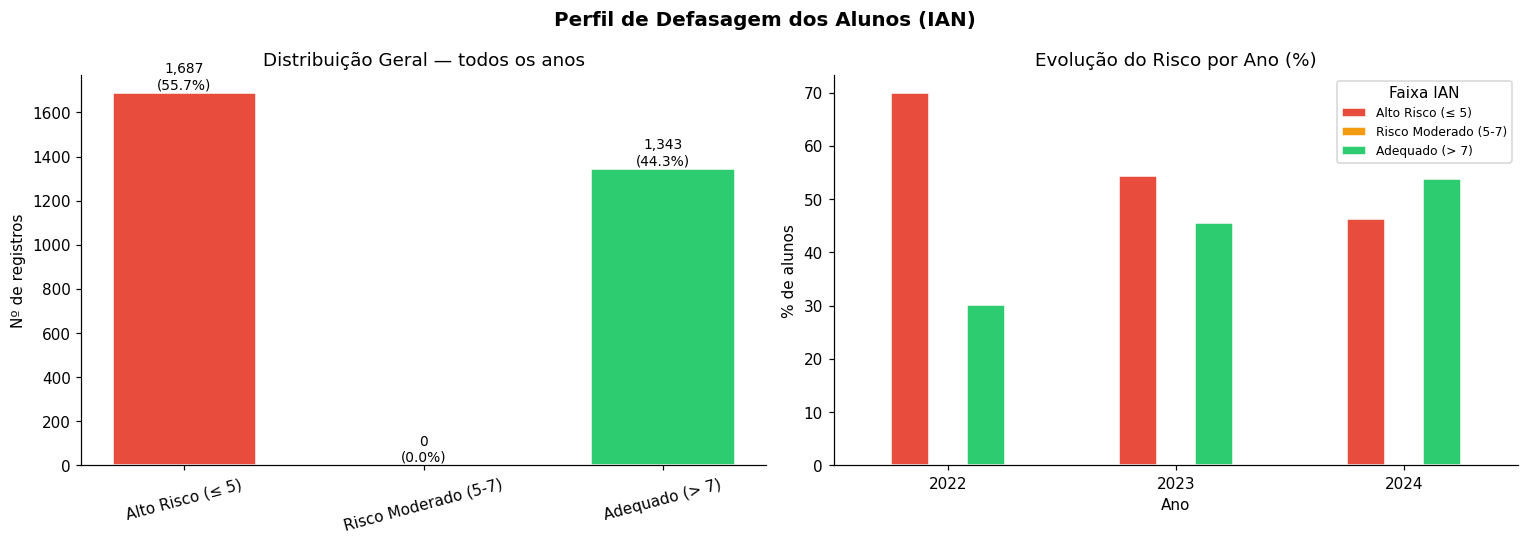


 ---> 55.7% dos registros estão em ALTO RISCO de defasagem (IAN ≤ 5)
faixa_ian
Alto Risco (≤ 5)        1687
Risco Moderado (5-7)       0
Adequado (> 7)          1343


In [15]:
# ─── LIMPEZA BASE (para EDA) ──────────────────────────────────────────────────
sys.path.insert(0, ".")
from utils_pm import limpar_base

df = limpar_base(df_raw)
print("Shape após limpeza:", df.shape)

# ─── Perfil de Defasagem (IAN) ──────────────────────────────────────────
# IAN <= 5 = Alto risco | 5 < IAN <= 7 = Moderado | IAN > 7 = Adequado
def classificar_ian(s):
    return pd.cut(s, bins=[-0.01, 5.0, 7.0, 10.1],
                    labels=["Alto Risco (≤ 5)", "Risco Moderado (5-7)", "Adequado (> 7)"])

df["faixa_ian"] = classificar_ian(df["ian"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Perfil de Defasagem dos Alunos (IAN)", fontweight="bold", fontsize=13)
cores = ["#E74C3C", "#F39C12", "#2ECC71"]

counts = df["faixa_ian"].value_counts().sort_index()
bars = axes[0].bar(counts.index.astype(str), counts.values, color=cores, edgecolor="white", width=0.6)
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height()+5,
                    f"{v:,}\n({v/counts.sum()*100:.1f}%)", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Distribuição Geral — todos os anos")
axes[0].set_ylabel("Nº de registros")
axes[0].tick_params(axis="x", rotation=15)

if "ano_pede" in df.columns:
    ev = (df.groupby(["ano_pede", "faixa_ian"]).size()
            .unstack(fill_value=0)
            .apply(lambda x: x/x.sum()*100, axis=1))
    ev.plot(kind="bar", ax=axes[1], color=cores, edgecolor="white", rot=0)
    axes[1].set_title("Evolução do Risco por Ano (%)")
    axes[1].set_xlabel("Ano")
    axes[1].set_ylabel("% de alunos")
    axes[1].legend(title="Faixa IAN", fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig(PROC_DIR / "q1_ian_defasagem.png", bbox_inches="tight")
plt.show()

pct = (df["faixa_ian"] == "Alto Risco (≤ 5)").mean()
print(f"\n ---> {pct:.1%} dos registros estão em ALTO RISCO de defasagem (IAN ≤ 5)")
print(df["faixa_ian"].value_counts().sort_index().to_string())


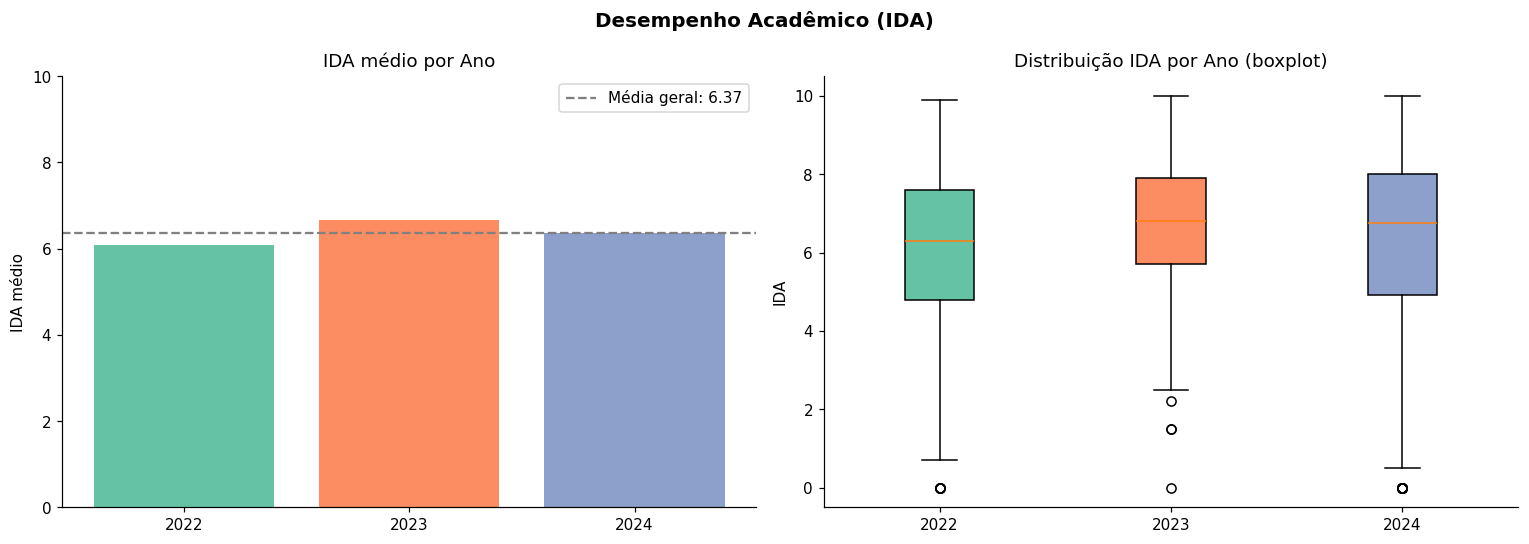


 ---> IDA médio por ano: variável
ano_pede
2022    6.092907
2023    6.663394
2024    6.351422


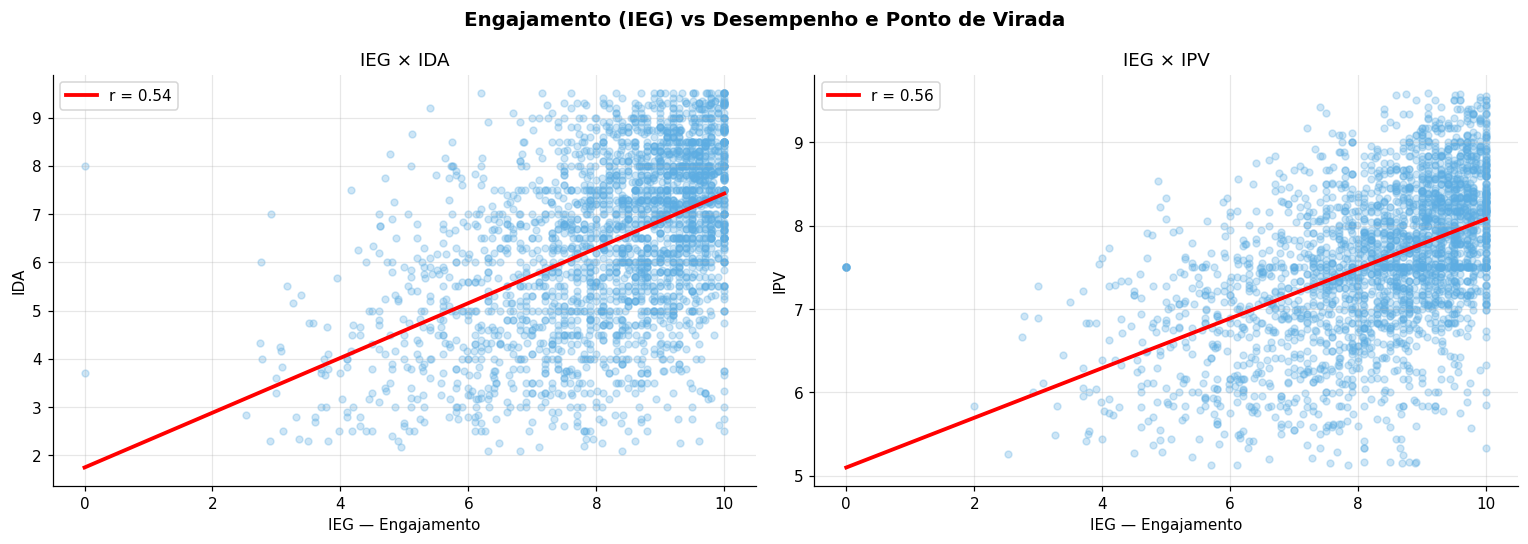


 ---> Correlações com IEG:
  IEG × IDA: r = 0.539
    → Relação POSITIVA moderada: quando IEG sobe, IDA tende a subir.
  IEG × IPV: r = 0.558
    → Relação POSITIVA moderada: quando IEG sobe, IPV tende a subir.


In [16]:
# ─── Q2: Desempenho Acadêmico (IDA) ao longo do tempo ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Desempenho Acadêmico (IDA)", fontweight="bold", fontsize=13)

ida_ano = df.groupby("ano_pede")["ida"].mean()
axes[0].bar(ida_ano.index.astype(str), ida_ano.values,
            color=sns.color_palette(PALETTE, len(ida_ano)))
axes[0].axhline(ida_ano.mean(), ls="--", color="gray", label=f"Média geral: {ida_ano.mean():.2f}")
axes[0].set_title("IDA médio por Ano")
axes[0].set_ylabel("IDA médio")
axes[0].set_ylim(0, 10)
axes[0].legend()

anos = sorted(df["ano_pede"].dropna().unique())
data_bp = [df.loc[df["ano_pede"]==a, "ida"].dropna().values for a in anos]
bp = axes[1].boxplot(data_bp, labels=[str(int(a)) for a in anos], patch_artist=True)
for patch, c in zip(bp["boxes"], sns.color_palette(PALETTE, len(anos))):
    patch.set_facecolor(c)
axes[1].set_title("Distribuição IDA por Ano (boxplot)")
axes[1].set_ylabel("IDA")

plt.tight_layout()
plt.savefig(PROC_DIR / "q2_ida.png", bbox_inches="tight")
plt.show()

tendencia = ("melhorando" if ida_ano.is_monotonic_increasing
                else ("caindo" if ida_ano.is_monotonic_decreasing else "variável"))
print(f"\n ---> IDA médio por ano: {tendencia}")
print(ida_ano.to_string())

# ─── Engajamento (IEG) × IDA e IPV ───────────────────────────────────────
alvos_q3 = [c for c in ["ida", "ipv"] if c in df.columns]

fig, axes = plt.subplots(1, len(alvos_q3), figsize=(7*len(alvos_q3), 5))
if len(alvos_q3) == 1:
    axes = [axes]
fig.suptitle("Engajamento (IEG) vs Desempenho e Ponto de Virada", fontweight="bold", fontsize=13)

for i, tgt in enumerate(alvos_q3):
    sub = df[["ieg", tgt]].dropna()
    r = sub.corr().iloc[0, 1]
    
    # Remove outliers extremos para melhor visualização (mantém 95% dos dados)
    q_low, q_high = sub[[tgt]].quantile([0.025, 0.975]).values.flatten()
    sub_clean = sub[(sub[tgt] >= q_low) & (sub[tgt] <= q_high)]
    
    axes[i].scatter(sub_clean["ieg"], sub_clean[tgt], alpha=0.3, s=20, color="#5DADE2")
    z = np.polyfit(sub_clean["ieg"], sub_clean[tgt], 1)
    xs = np.linspace(sub_clean["ieg"].min(), sub_clean["ieg"].max(), 100)
    axes[i].plot(xs, np.poly1d(z)(xs), "r-", lw=2.5, label=f"r = {r:.2f}")
    axes[i].set_title(f"IEG × {tgt.upper()}")
    axes[i].set_xlabel("IEG — Engajamento")
    axes[i].set_ylabel(tgt.upper())
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PROC_DIR / "q3_ieg.png", bbox_inches="tight")
plt.show()

print("\n ---> Correlações com IEG:")
for col in alvos_q3:
    sub = df[["ieg", col]].dropna()
    r_val = sub.corr().iloc[0,1]
    print(f"  IEG × {col.upper()}: r = {r_val:.3f}")
    if r_val > 0.3:
        print(f"    → Relação POSITIVA moderada: quando IEG sobe, {col.upper()} tende a subir.")
    elif r_val > 0:
        print(f"    → Relação POSITIVA fraca: tendência de {col.upper()} subir com IEG, mas com alta variabilidade.")


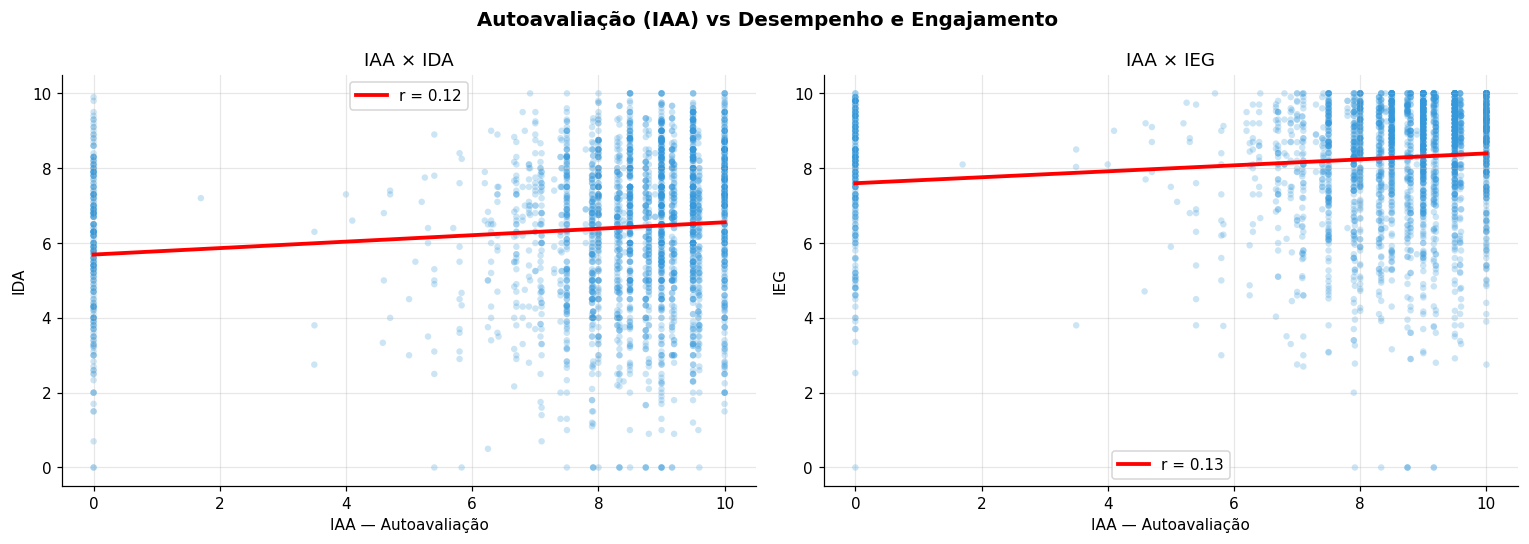


 ---> Gap médio IAA − IDA = 1.55
  → Alunos tendem a SUPERESTIMAR seu desempenho.
  → Correlação IAA×IDA: r = 0.115


In [17]:
# ─── Autoavaliação (IAA) × IDA e IEG ────────────────────────────────────
alvos_q4 = [c for c in ["ida", "ieg"] if c in df.columns]
fig, axes = plt.subplots(1, len(alvos_q4), figsize=(7*len(alvos_q4), 5))
fig.suptitle(" Autoavaliação (IAA) vs Desempenho e Engajamento", fontweight="bold", fontsize=13)
if len(alvos_q4) == 1: axes = [axes]

for i, tgt in enumerate(alvos_q4):
    sub = df[["iaa", tgt]].dropna()
    r = sub.corr().iloc[0, 1]
    
    # Scatter plot com linha de regressão
    axes[i].scatter(sub["iaa"], sub[tgt], alpha=0.25, s=18, color="#3498DB", edgecolors='none')
    z = np.polyfit(sub["iaa"], sub[tgt], 1)
    xs = np.linspace(sub["iaa"].min(), sub["iaa"].max(), 100)
    axes[i].plot(xs, np.poly1d(z)(xs), "r-", lw=2.5, label=f"r = {r:.2f}")
    axes[i].set_title(f"IAA × {tgt.upper()}")
    axes[i].set_xlabel("IAA — Autoavaliação")
    axes[i].set_ylabel(tgt.upper())
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PROC_DIR / "q4_iaa.png", bbox_inches="tight")
plt.show()

# Analise IDA
sub = df[["iaa", "ida"]].dropna()
gap = (sub["iaa"] - sub["ida"]).mean()
print(f"\n ---> Gap médio IAA − IDA = {gap:.2f}")
interp = "SUPERESTIMAR" if gap > 0.5 else ("SUBESTIMAR" if gap < -0.5 else "AVALIAR CORRETAMENTE")
print(f"  → Alunos tendem a {interp} seu desempenho.")
print(f"  → Correlação IAA×IDA: r = {sub.corr().iloc[0,1]:.3f}")




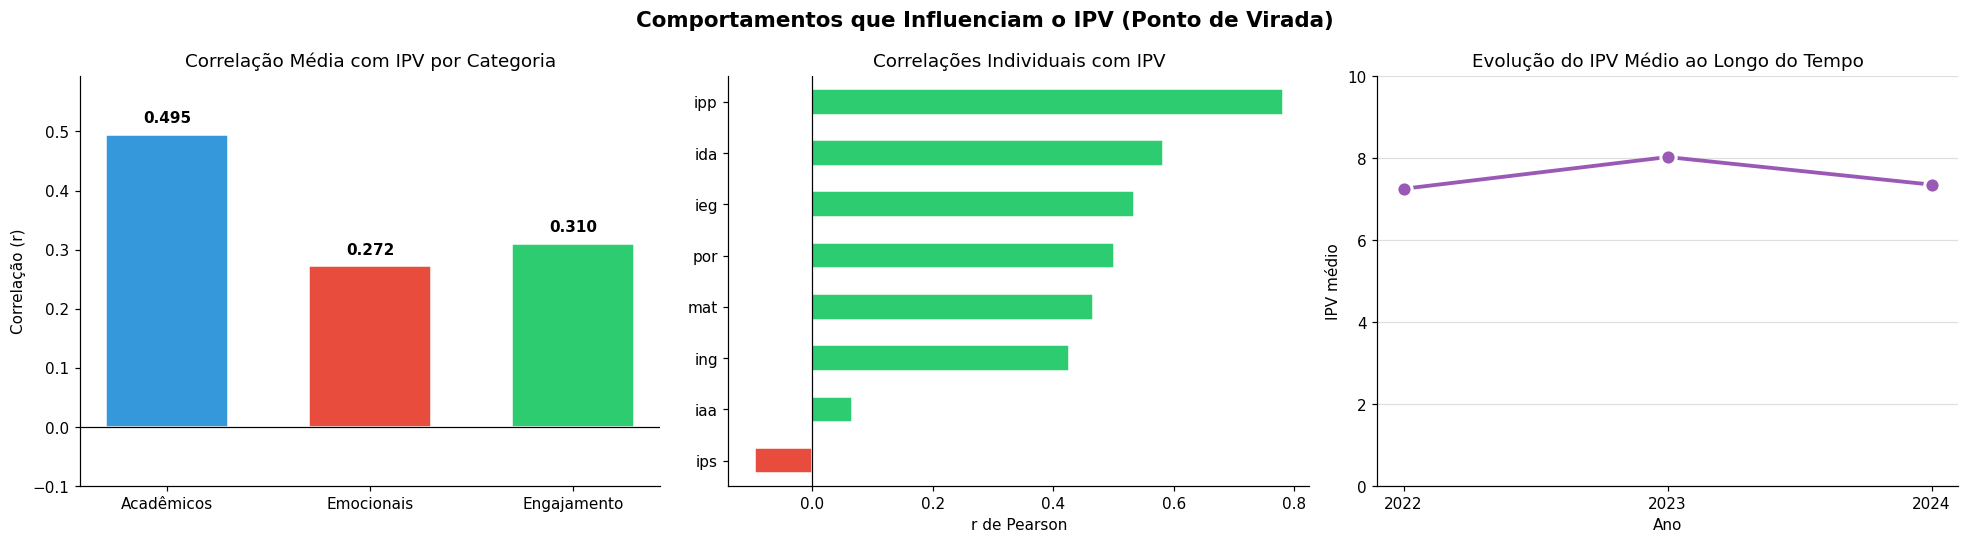


 ---> Influência no IPV por categoria de comportamento:
  Acadêmicos     : r médio = 0.495
  Emocionais     : r médio = 0.272
  Engajamento    : r médio = 0.310

  → Categoria com MAIOR influência: Acadêmicos (r = 0.495)


In [18]:
# ─── IPV — Comportamentos que mais Influenciam ───────────────────────────
# Categorizar indicadores segundo a descrição fornecida
academicos = [c for c in ["ida", "mat", "por", "ing"] if c in df.columns]  # Desempenho acadêmico
emocionais = [c for c in ["ips", "ipp"] if c in df.columns]                 # Psicossocial + Psicopedagógico
engajamento = [c for c in ["ieg", "iaa"] if c in df.columns]                # Engajamento + Autoavaliação

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Comportamentos que Influenciam o IPV (Ponto de Virada)", fontweight="bold", fontsize=14)

# Plot 1: Correlações por categoria
categorias = []
if academicos:
    corrs_acad = df[["ipv"] + academicos].dropna().corr()["ipv"].drop("ipv")
    categorias.append(("Acadêmicos", corrs_acad.mean(), "#3498DB"))
if emocionais:
    corrs_emo = df[["ipv"] + emocionais].dropna().corr()["ipv"].drop("ipv")
    categorias.append(("Emocionais", corrs_emo.mean(), "#E74C3C"))
if engajamento:
    corrs_eng = df[["ipv"] + engajamento].dropna().corr()["ipv"].drop("ipv")
    categorias.append(("Engajamento", corrs_eng.mean(), "#2ECC71"))

nomes_cat = [c[0] for c in categorias]
valores_cat = [c[1] for c in categorias]
cores_cat = [c[2] for c in categorias]

bars = axes[0].bar(nomes_cat, valores_cat, color=cores_cat, edgecolor="white", width=0.6)
for bar, val in zip(bars, valores_cat):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Correlação Média com IPV por Categoria")
axes[0].set_ylabel("Correlação (r)")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_ylim(-0.1, max(valores_cat) * 1.2)

# Plot 2: Correlações individuais detalhadas
todos_ind = academicos + emocionais + engajamento
if todos_ind:
    corrs_ind = df[["ipv"] + todos_ind].dropna().corr()["ipv"].drop("ipv").sort_values()
    cores_ind = ["#E74C3C" if v < 0 else "#2ECC71" for v in corrs_ind.values]
    corrs_ind.plot(kind="barh", ax=axes[1], color=cores_ind, edgecolor="white")
    axes[1].axvline(0, color="black", lw=0.8)
    axes[1].set_title("Correlações Individuais com IPV")
    axes[1].set_xlabel("r de Pearson")

# Plot 3: Evolução temporal do IPV por ano
if "ano_pede" in df.columns:
    ipv_ano = df.groupby("ano_pede")["ipv"].mean()
    axes[2].plot(ipv_ano.index.astype(str), ipv_ano.values, marker="o",
                    color="#9B59B6", lw=2.5, ms=10, markeredgecolor="white", markeredgewidth=2)
    axes[2].set_title("Evolução do IPV Médio ao Longo do Tempo")
    axes[2].set_ylabel("IPV médio")
    axes[2].set_xlabel("Ano")
    axes[2].set_ylim(0, 10)
    axes[2].grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig(PROC_DIR / "q7_ipv.png", bbox_inches="tight")
plt.show()

print("\n ---> Influência no IPV por categoria de comportamento:")
for nome, valor, _ in categorias:
    print(f"  {nome:15s}: r médio = {valor:.3f}")

if categorias:
    maior = max(categorias, key=lambda x: abs(x[1]))
    print(f"\n  → Categoria com MAIOR influência: {maior[0]} (r = {maior[1]:.3f})")


---
## 2 — Modelagem Preditiva (Pergunta 9)

> **Objetivo:** Identificar alunos em risco de defasagem antes da queda de desempenho.
>
> **Target:** `risco_defasagem = 1` se `IAN ≤ 5` (alto risco), `0` caso contrário.
>

In [8]:
# ─── ENGENHARIA DE FEATURES (via utils_pm) ───────────────────────────────────
from utils_pm import preparar_features, construir_preprocessador

df_ml = preparar_features(df_raw, modo_treino=True)

# ─── LIMPEZA DE TIPOS: remover colunas datetime e garantir tipos compatíveis ───
# Remove colunas com tipos datetime que causam problemas no sklearn
datetime_cols = df_ml.select_dtypes(include=['datetime64', 'datetime']).columns.tolist()
if datetime_cols:
    print(f"⚠️  Removendo {len(datetime_cols)} colunas datetime: {datetime_cols}")
    df_ml = df_ml.drop(columns=datetime_cols)

# Converte colunas object para string (exceto target e ano_pede)
for col in df_ml.columns:
    if col not in ['risco_defasagem', 'ano_pede']:
        # Se for object e não numérica, tenta converter para string
        if df_ml[col].dtype == 'object':
            # Tenta converter para numérico primeiro
            df_ml[col] = pd.to_numeric(df_ml[col], errors='ignore')
            # Se ainda for object, converte para string
            if df_ml[col].dtype == 'object':
                df_ml[col] = df_ml[col].astype(str).replace('nan', np.nan)

print("Shape após feature engineering:", df_ml.shape)
print("\nColunas resultantes:")
print(df_ml.columns.tolist())
print("\nTipos de dados:")
print(df_ml.dtypes.value_counts())
print("\nBalanceamento do target:")
print(df_ml["risco_defasagem"].value_counts())
print("Dataset está balanceado")


Shape após feature engineering: (3030, 25)

Colunas resultantes:
['genero', 'idade', 'fase_ideal', 'mat', 'por', 'ing', 'iaa', 'ieg', 'ips', 'ipp', 'ida', 'ipv', 'inde_2023', 'n_av', 'media_academica', 'std_notas', 'media_comportamental', 'risco_psico', 'miss_iaa', 'miss_ieg', 'miss_ips', 'miss_ipp', 'miss_ida', 'miss_ipv', 'risco_defasagem']

Tipos de dados:
float64    17
int64       7
object      1
Name: count, dtype: int64

Balanceamento do target:
risco_defasagem
1    1687
0    1343
Name: count, dtype: int64
Dataset está balanceado


In [10]:

# ─── SPLIT TREINO / TESTE (estratificado) ─────────────────────────────────────
IGNORAR = ["risco_defasagem"]
colunas_para_dropar = [col for col in IGNORAR if col in df_ml.columns]

# Separa o DataFrame completo em Features (X) e Target (y)
X = df_ml.drop(columns=colunas_para_dropar)
y = df_ml["risco_defasagem"].astype(int)

# Realiza a divisão em treino e teste 
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.30,   
    random_state=42,    
    stratify=y           
)

# Imprime os resultados para validação
print(f"Treino : {X_train.shape}  | risco=1: {y_train.mean():.2%}")
print(f"Teste  : {X_test.shape}  | risco=1: {y_test.mean():.2%}")

# ─── PIPELINE DE PRÉ-PROCESSAMENTO ────────────────────────────────────────────
preprocess = construir_preprocessador(X_train)

# ─── MODELOS ──────────────────────────────────────────────────────────────────
models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample",
                                           random_state=SEED, n_jobs=-1),
    "SVC": SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=SEED),
}


# ─── VALIDAÇÃO CRUZADA (5-fold estratificada) ──────────────────────────────────
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {"acc": "accuracy", "roc_auc": "roc_auc", "pr_auc": "average_precision"}
cv_results, pipes = [], {}

print("\n" + "="*65)
print(" RESULTADOS DA VALIDAÇÃO CRUZADA (TESTE DE ESTABILIDADE) ")
print("="*65)

for name, clf in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", clf)])
    pipes[name] = pipe
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring,
                            n_jobs=-1, return_train_score=False)
    
    # Formatando as métricas para facilitar a leitura
    row = {
        "Modelo": name,
        "Acurácia Geral (%)": f"{scores['test_acc'].mean():.2%} ± {scores['test_acc'].std():.2%}",
        "Separação de Risco (ROC)": f"{scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}",
        "Foco no Risco (PR)":  f"{scores['test_pr_auc'].mean():.3f} ± {scores['test_pr_auc'].std():.3f}",
        "_roc": scores["test_roc_auc"].mean(), # Usado apenas para ordenação, se quiser
    }
    cv_results.append(row)
    
    print(f"\n🔸 Modelo: {name}")
    print(f"  • Acerto Geral (Acurácia)       : {row['Acurácia Geral (%)']}")
    print(f"  • Capacidade de Separar Classes : {row['Separação de Risco (ROC)']} (Máximo 1.0)")
    print(f"  • Assertividade nos Casos Críticos: {row['Foco no Risco (PR)']} (Máximo 1.0)")

# Criando um DataFrame consolidado
cv_df = pd.DataFrame(cv_results).drop("_roc", axis=1)

print("\n" + "-"*65)
print(" RESUMO COMPARATIVO DOS MODELOS:")
print("-"*65)
display(cv_df)


Treino : (2121, 24)  | risco=1: 55.68%
Teste  : (909, 24)  | risco=1: 55.67%

 RESULTADOS DA VALIDAÇÃO CRUZADA (TESTE DE ESTABILIDADE) 

🔸 Modelo: LogReg
  • Acerto Geral (Acurácia)       : 77.13% ± 2.03%
  • Capacidade de Separar Classes : 0.847 ± 0.019 (Máximo 1.0)
  • Assertividade nos Casos Críticos: 0.830 ± 0.032 (Máximo 1.0)

🔸 Modelo: RandomForest
  • Acerto Geral (Acurácia)       : 87.18% ± 1.61%
  • Capacidade de Separar Classes : 0.939 ± 0.010 (Máximo 1.0)
  • Assertividade nos Casos Críticos: 0.939 ± 0.013 (Máximo 1.0)

🔸 Modelo: SVC
  • Acerto Geral (Acurácia)       : 83.26% ± 1.39%
  • Capacidade de Separar Classes : 0.902 ± 0.017 (Máximo 1.0)
  • Assertividade nos Casos Críticos: 0.901 ± 0.022 (Máximo 1.0)

-----------------------------------------------------------------
 RESUMO COMPARATIVO DOS MODELOS:
-----------------------------------------------------------------


,Modelo,Acurácia Geral (%),Separação de Risco (ROC),Foco no Risco (PR)
0,LogReg,77.13% ± 2.03%,0.847 ± 0.019,0.830 ± 0.032
1,RandomForest,87.18% ± 1.61%,0.939 ± 0.010,0.939 ± 0.013
2,SVC,83.26% ± 1.39%,0.902 ± 0.017,0.901 ± 0.022



 AVALIAÇÃO FINAL NO CONJUNTO DE TESTE 

🔹 MODELO: LogReg
Capacidade de Separação (ROC AUC) : 0.798 (Máximo 1.0)

📊 Relatório de Classificação:
               precision    recall  f1-score   support

Sem Risco (0)       0.66      0.74      0.70       403
Com Risco (1)       0.77      0.70      0.73       506

     accuracy                           0.72       909
    macro avg       0.71      0.72      0.71       909
 weighted avg       0.72      0.72      0.72       909



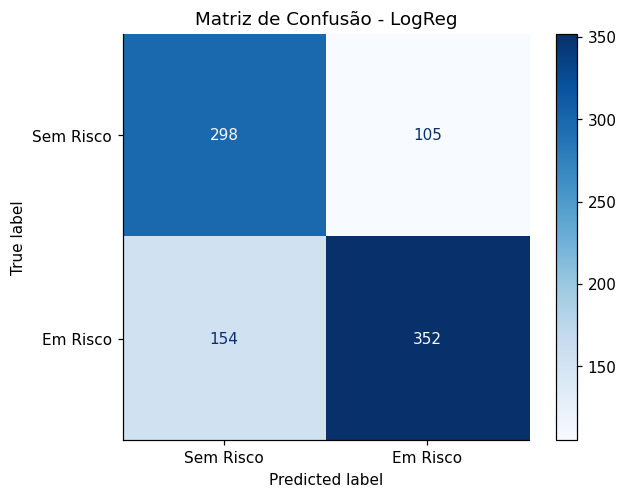


🔹 MODELO: RandomForest
Capacidade de Separação (ROC AUC) : 0.923 (Máximo 1.0)

📊 Relatório de Classificação:
               precision    recall  f1-score   support

Sem Risco (0)       0.88      0.75      0.81       403
Com Risco (1)       0.82      0.92      0.87       506

     accuracy                           0.84       909
    macro avg       0.85      0.83      0.84       909
 weighted avg       0.85      0.84      0.84       909



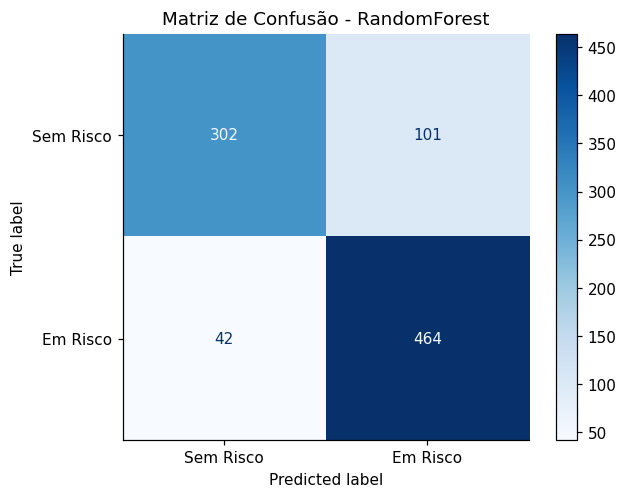


🔹 MODELO: SVC
Capacidade de Separação (ROC AUC) : 0.870 (Máximo 1.0)

📊 Relatório de Classificação:
               precision    recall  f1-score   support

Sem Risco (0)       0.76      0.76      0.76       403
Com Risco (1)       0.81      0.81      0.81       506

     accuracy                           0.79       909
    macro avg       0.79      0.79      0.79       909
 weighted avg       0.79      0.79      0.79       909



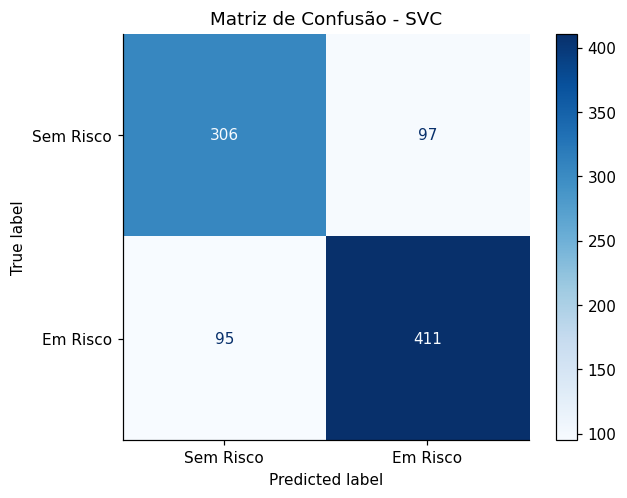


------------------------------------------------------------
 🏆 RANKING FINAL DOS MODELOS (Pela Métrica ROC AUC)
------------------------------------------------------------


,Modelo,ROC_AUC
1,RandomForest,0.922883
2,SVC,0.869700
0,LogReg,0.798066



✅ O modelo escolhido como definitivo para produção é: **RandomForest**


In [11]:
# ─── AVALIAÇÃO NO CONJUNTO DE TESTE  ────────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay
test_rows, fitted_pipes = [], {}

print("\n" + "="*60)
print(" AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ")
print("="*60)

for name, pipe in pipes.items():
    # Treina o modelo completo
    pipe.fit(X_train, y_train)
    fitted_pipes[name] = pipe
    
    # Faz as previsões usando o corte padrão e intuitivo de 50%
    y_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred  = pipe.predict(X_test)

    # Calcula a capacidade de separação geral (ROC AUC)
    roc = roc_auc_score(y_test, y_proba)
    
    print(f"\n{'='*40}")
    print(f"🔹 MODELO: {name}")
    print(f"{'='*40}")
    print(f"Capacidade de Separação (ROC AUC) : {roc:.3f} (Máximo 1.0)\n")
    
    # Exibe o Relatório de Classificação (Foco na linha "1", que é o Risco)
    print("📊 Relatório de Classificação:")
    print(classification_report(y_test, y_pred, target_names=["Sem Risco (0)", "Com Risco (1)"]))
    
    # Salva os resultados para o ranking final
    test_rows.append({"Modelo": name, "ROC_AUC": roc})

    # Plota a Matriz de Confusão visual e amigável
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sem Risco", "Em Risco"])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Matriz de Confusão - {name}')
    plt.show()

# ─── RANKING FINAL E ESCOLHA DO MELHOR MODELO ─────────────────────────────────
test_df_res = pd.DataFrame(test_rows).sort_values("ROC_AUC", ascending=False)

print("\n" + "-"*60)
print(" 🏆 RANKING FINAL DOS MODELOS (Pela Métrica ROC AUC)")
print("-"*60)
display(test_df_res)

# Seleciona o primeiro colocado automaticamente
BEST_MODEL_NAME = test_df_res.iloc[0]["Modelo"]
best_pipe = fitted_pipes[BEST_MODEL_NAME]

print(f"\n✅ O modelo escolhido como definitivo para produção é: **{BEST_MODEL_NAME}**")

In [12]:
import joblib
import numpy as np

# ─── DEFINIÇÃO DO THRESHOLD ───────────────────────────────────────────────────
# Definido como 0.4 para priorizar a identificação de alunos em risco, mesmo que isso gere mais falsos positivos.
THRESHOLD = 0.4

# ─── SALVAR ARTEFATOS ─────────────────────────────────────────────────────────
MODEL_PATH   = MODELS_DIR / "modelo_passos_magicos.pkl"
CFG_PATH     = MODELS_DIR / "config_passos_magicos.pkl"
FEATS_PATH   = MODELS_DIR / "feature_names.pkl"

joblib.dump(best_pipe, MODEL_PATH)
# Atualizado para salvar o THRESHOLD fixo
joblib.dump({"threshold": THRESHOLD, "best_model": BEST_MODEL_NAME}, CFG_PATH)
joblib.dump(X_train.columns.tolist(), FEATS_PATH)

print("✅ Artefatos salvos:")
print(f"  • Modelo    : {MODEL_PATH}")
print(f"  • Config    : {CFG_PATH}")
print(f"  • Features  : {FEATS_PATH}")
print(f"\n  Threshold padrão adotado: {THRESHOLD:.2f}")
print(f"  Melhor modelo:            {BEST_MODEL_NAME}")

✅ Artefatos salvos:
  • Modelo    : modelo\modelo_passos_magicos.pkl
  • Config    : modelo\config_passos_magicos.pkl
  • Features  : modelo\feature_names.pkl

  Threshold padrão adotado: 0.40
  Melhor modelo:            RandomForest
